In [18]:
import os
import glob

import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from scipy.ndimage import rotate



### Working with the i'-band solution for the 20230309_10 HR4796A dataset

In [6]:
# Allocate the dirs of interest
basedir = os.environ["HOME"] + "/data"
obs_dir = f"{basedir}/HR4796a_lco2023a_magao-x_20230309_10"
iband_wdhlib_dir = f"{obs_dir}/raws_20230310T054736_s_lyot_stop/camsci1/lite_wdhlib"
iband_wdhlib = glob.glob(f"{iband_wdhlib_dir}/camsci1_*parang.fits")

# Load the model components
wind_fm_files = os.path.join(iband_wdhlib_dir, "wind_fm_files")
windfit_MCMC = os.path.join(iband_wdhlib_dir, "windfit_MCMC")
file_prefix = "camsci1_i_20230309_10"
fname_bestmodel1 = f"{windfit_MCMC}/camsci1_i_20230309_10_backend_file_mcmc_BestModel_comp1.fits"
fname_bestmodel2 = f"{windfit_MCMC}/camsci1_i_20230309_10_backend_file_mcmc_BestModel_comp2.fits"

bestmodel1 = fits.getdata(fname_bestmodel1)
bestmodel2 = fits.getdata(fname_bestmodel2)


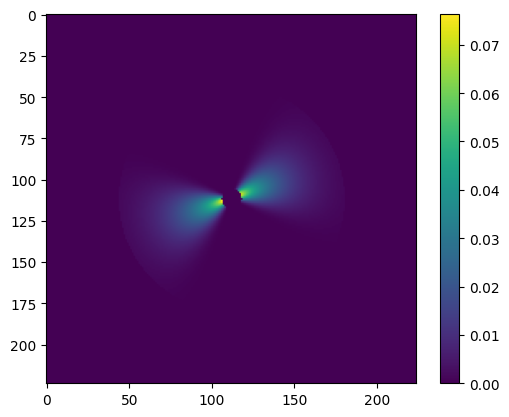

In [82]:
# Turn the model components into a modal basis


wind_mode1 = bestmodel1 / np.sqrt(np.sum(bestmodel1**2))
wind_mode2 = bestmodel2 / np.sqrt(np.sum(bestmodel2**2))

plt.imshow(wind_mode1)
plt.colorbar()



### Load the PSF library

In [44]:
psf_lib = []
lib_headers = []
for fname in iband_wdhlib:
    psf_lib.append(fits.getdata(fname))
    lib_headers.append(fits.getheader(fname))

psf_lib = np.array(psf_lib)
mean_stack = np.mean(psf_lib, axis=0)



Working with PSF /Users/jkueny/data/HR4796a_lco2023a_magao-x_20230309_10/raws_20230310T054736_s_lyot_stop/camsci1/lite_wdhlib/camsci1_2x2bin_2.0_parang.fits
(50176, 2)
65999.16800656191 2223.7296093157765


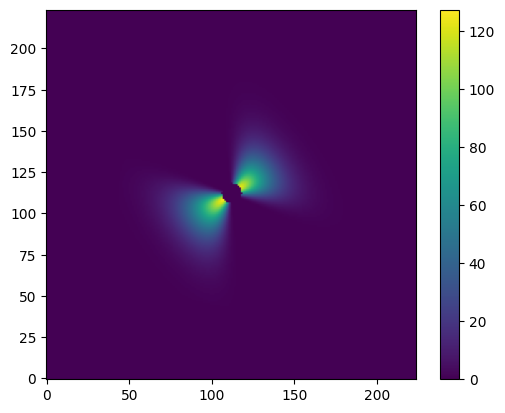

In [84]:
# Test projection of a PSF image onto the wind modes
test_ind = 30
print(f"Working with PSF {iband_wdhlib[test_ind]}")
test_psf_image, test_header = psf_lib[test_ind], lib_headers[test_ind]

mean_of_test_psf = np.mean(test_psf_image)

test_psf_meansub = test_psf_image

# Rotate the wind components by the parang
wind_mode1_rot = rotate(wind_mode1, -test_header["PARANG"], reshape=False)
wind_mode2_rot = rotate(wind_mode2, -test_header["PARANG"], reshape=False)

wind_mode1_vec = wind_mode1_rot.reshape(wind_mode1_rot.shape[0] * wind_mode1_rot.shape[1])
wind_mode2_vec = wind_mode2_rot.reshape(wind_mode2_rot.shape[0] * wind_mode2_rot.shape[1])

wind_modes = np.column_stack((wind_mode1_vec, wind_mode2_vec))

print(wind_modes.shape)

test_psf_vec = test_psf_meansub.reshape(test_psf_meansub.shape[0] * test_psf_meansub.shape[1])

# coeffs, _, _, _ = np.linalg.lstsq(wind_modes, test_psf_vec, rcond=None)

# c1, c2 = coeffs

# Project the PSF image onto the wind modes
wind_mode1_coeff = np.inner(wind_mode1_vec, test_psf_vec) #/ np.sum(wind_mode1_vec**2)
wind_mode2_coeff = np.inner(wind_mode2_vec, test_psf_vec) #/ np.sum(wind_mode2_vec**2)

print(wind_mode1_coeff, wind_mode2_coeff)

# View the mode scaled by the coefficients
wind_mode1_scaled = wind_mode1 * wind_mode1_coeff
wind_mode2_scaled = wind_mode2 * wind_mode2_coeff

combined = wind_mode1_scaled + wind_mode2_scaled

plt.imshow(wind_mode2_scaled, origin="lower")
plt.colorbar()


